In [5]:
import numpy as np
import json

In [6]:
# =========================
# KBRS cache/lookup arguments (Jupyter block)
# =========================

# ---- replays ----
REPLAYS = [275]  # 예: [275, 3613, 4664]

# ---- data paths ----
DATA_ROOT   = "/workspace/data"
INPUT_ROOT  = f"{DATA_ROOT}/input/dst"
LABEL_ROOT  = f"{DATA_ROOT}/label/dst"
LABEL_METHOD = "all_correct"

# ---- channel selection (11 -> 9) ----
# config.yaml: include_components
INCLUDE_COMPONENTS = ["worker", "ground", "air", "building", "vision"]

# config.py: Channel Enum index order (11 channels)
# 0:P1W,1:P1G,2:P1A,3:P1B,4:P2W,5:P2G,6:P2A,7:P2B,8:Resource,9:Vision,10:Terrain
COMPONENT_CHANNEL_MAP = {
    "worker":   [0, 4],
    "ground":   [1, 5],
    "air":      [2, 6],
    "building": [3, 7],
    "resource": [8],
    "vision":   [9],
    "terrain":  [10],
}

# build selected channels in original 11ch space
SELECTED_CHANNELS_11 = []
for comp in INCLUDE_COMPONENTS:
    SELECTED_CHANNELS_11.extend(COMPONENT_CHANNEL_MAP[comp])
# keep deterministic order, unique
SELECTED_CHANNELS_11 = list(dict.fromkeys(SELECTED_CHANNELS_11))
# expected (for worker/ground/air/building/vision): [0,1,2,3,4,5,6,7,9]
print("SELECTED_CHANNELS_11 =", SELECTED_CHANNELS_11)

# Build mapping: original_index -> new_index (after selecting to 9ch)
REMAPPING_11_TO_9 = {ch: i for i, ch in enumerate(SELECTED_CHANNELS_11)}
print("REMAPPING_11_TO_9 =", REMAPPING_11_TO_9)
# In this setup, original 9(Vision) becomes new index 8.

# ---- KBRS scorer params (from config.py KBRS_PARAMS) ----
# IMPORTANT: PyTorch conv2d uses (kH, kW)
REGION_SIZE_KH_KW = (20, 12)   # from KBRS_PARAMS['region_size']
SCORE_STRIDE      = 1          # KBRS_PARAMS['score_stride']
DOWNSAMPLE_BEFORE = None       # KBRS_PARAMS['downsample_before']

SCORE_WEIGHTS = {"density": 0.3, "mixture": 3.0, "centeredness": 0.3}

# projections are defined over the *9ch* input (after selection)
PROJECTIONS_9 = {
    "A": [0, 1, 2, 3],
    "B": [4, 5, 6, 7],
}
MIXTURE_BETWEEN = ("A", "B")
MIXTURE_MODE    = "confusion"   # KBRS_PARAMS['mixture_mode']
MIXTURE_POWER   = 2.0           # KBRS_PARAMS['mixture_power']

# gate is also defined over *9ch* input (vision becomes index 8)
GATE_CHANNELS_9 = [8]           # KBRS_PARAMS['gate_channels']
GATE_REDUCE     = "mean"        # KBRS_PARAMS['gate_reduce']
GATE_GAIN       = 0.8           # KBRS_PARAMS['gate_gain']
# NOTE: gate 적용 방식은 상위 모델 로직을 봐야 정확히 동일하게 맞출 수 있음.
# 예: gate_map = 1 + gain * reduce(x[:, gate_channels])  또는 score_map *= (...)
GATE_APPLY_MODE = "unknown"     # "multiply" / "add" / etc. (상위 코드 확인 필요)

# ---- cache options ----
CACHE_ROOT   = f"{INPUT_ROOT}/__kbrs_cache__"  # 또는 f"{DATA_ROOT}/__kbrs_cache__"
CACHE_DTYPE  = "float16"  # "float16" or "float32"
REBUILD_CACHE = False
COMPRESS_NPZ  = True

# ---- runtime options ----
NUM_WORKERS = 32
CHUNKSIZE   = 1  # 진행도 정체/straggler 줄이려면 1~4 추천

# ---- lookup options (optional) ----
LOOKUP_SOURCE = "gt"  # "gt" or "pred"
BORDER_MODE   = "clamp"  # "clamp"|"skip"|"on_the_fly"

# pred only
PRED_ROOT  = "/workspace/predictions"
MODEL_NAME = None  # 예: "all_correct_win4_kbrs_fold1_s123_kbrs100_base_score_..."
EPOCH      = None  # 예: 30

CSV_OUT = None  # 예: "/tmp/kbrs_lookup.csv"

SELECTED_CHANNELS_11 = [0, 4, 1, 5, 2, 6, 3, 7, 9]
REMAPPING_11_TO_9 = {0: 0, 4: 1, 1: 2, 5: 3, 2: 4, 6: 5, 3: 6, 7: 7, 9: 8}


In [25]:
# npz_path = "9.kbrs.w20h12_sx1sy1_thr0p0.npz"
npz_path = "6.npz"

In [26]:
with np.load(npz_path, allow_pickle=True) as z:
    meta_json_str = str(z["meta_json"][0])
    meta = json.loads(meta_json_str)

In [27]:
meta

{'replay_id': '212',
 'image_id': 6,
 'file_name': 'input/dst/212/6.npy',
 'feat_path': '/workspace/data/input/dst/212.rep/6.npy',
 'feat_shape': [11, 128, 128],
 'selected_channels_11': [0, 4, 1, 5, 2, 6, 3, 7, 9],
 'selected_channel_names_11': ['Player_1_Worker',
  'Player_2_Worker',
  'Player_1_Ground',
  'Player_2_Ground',
  'Player_1_Air',
  'Player_2_Air',
  'Player_1_Building',
  'Player_2_Building',
  'Vision'],
 'region_size_kh_kw': [20, 12],
 'score_stride': 1,
 'downsample_before': None,
 'score_weights': {'density': 0.3, 'mixture': 3.0, 'centeredness': 0.3},
 'projections_9': {'A': [0, 1, 2, 3], 'B': [4, 5, 6, 7]},
 'mixture_mode': 'confusion',
 'mixture_power': 2.0,
 'gate_channels_9': [8],
 'gate_reduce': 'mean',
 'gate_gain': 0.8,
 'note': 'score_map is weighted sum of density/centeredness/mixture (gate not applied here).'}

In [28]:
npz = np.load(npz_path, allow_pickle=True)

In [29]:
from matplotlib import pyplot as plt

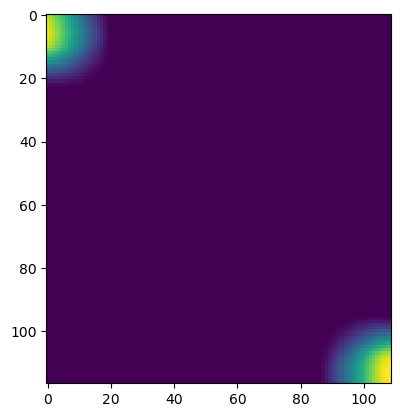

In [30]:
plt.imshow(npz['density'].T)

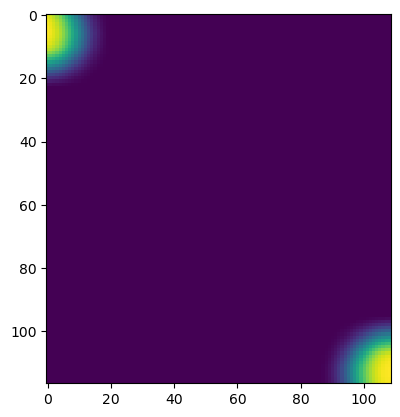

In [31]:
plt.imshow(npz['centeredness'].T)

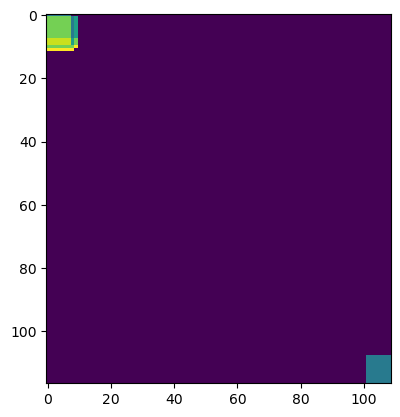

In [32]:
plt.imshow(npz['mixture'].T)

In [35]:
npz['mixture'].shape

(109, 117)

In [22]:
b

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 